In [1]:
!python --version


Python 3.12.13


In [22]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


Inport do CSV

In [3]:
input_csv = "size_impact.csv"
df = pd.read_csv(input_csv)

Features e target

In [4]:
features = df[[
  "PATH-OCURENCE",
  "PATHS-OCURENCE",
  "FA-IN",
  "FA-OUT" ,
  "LOGIC-LEVEL",
  "DEEP",
  "LOADED-CELLS",
  "CELL-AREA",
  "COST-AREA",
]]

target = df["DIF-ARRIVAL"]

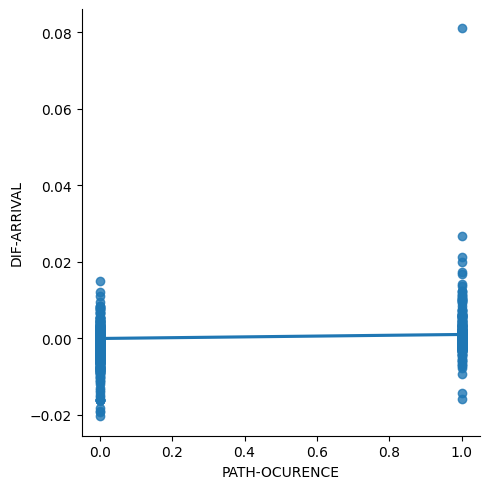

In [5]:
sns.lmplot(x="PATH-OCURENCE", y="DIF-ARRIVAL", data=df, order = 1, ci = None)

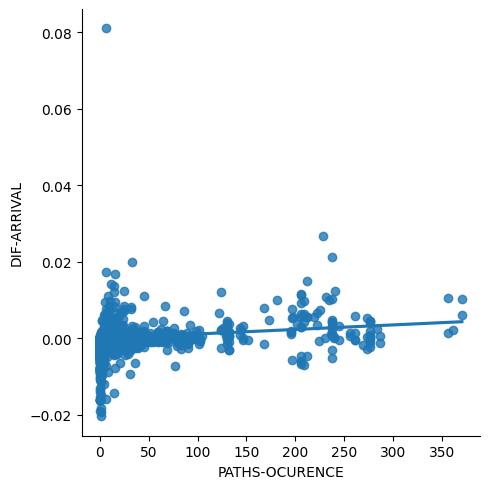

In [6]:
sns.lmplot(x="PATHS-OCURENCE", y="DIF-ARRIVAL", data=df, order = 1, ci = None)

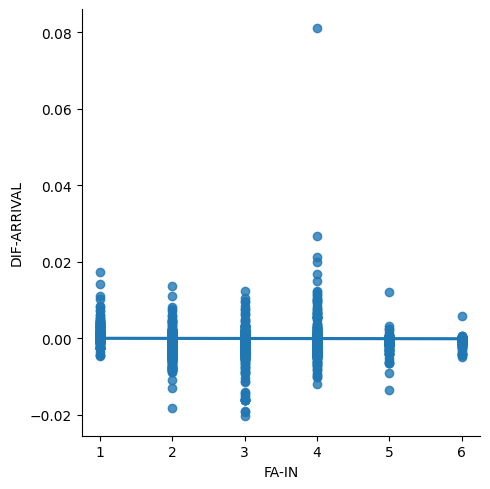

In [7]:
sns.lmplot(x="FA-IN", y="DIF-ARRIVAL", data=df, order = 1, ci = None)

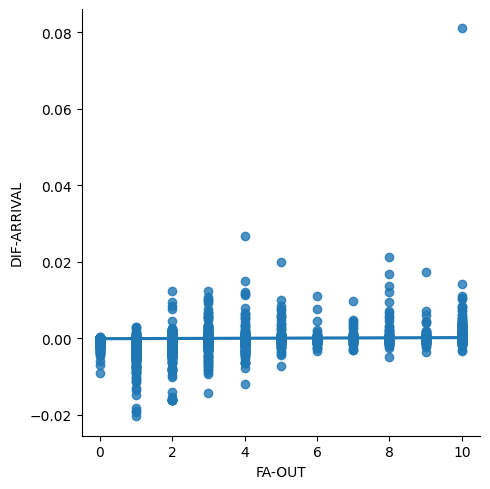

In [8]:
sns.lmplot(x="FA-OUT", y="DIF-ARRIVAL", data=df, order = 1, ci = None)

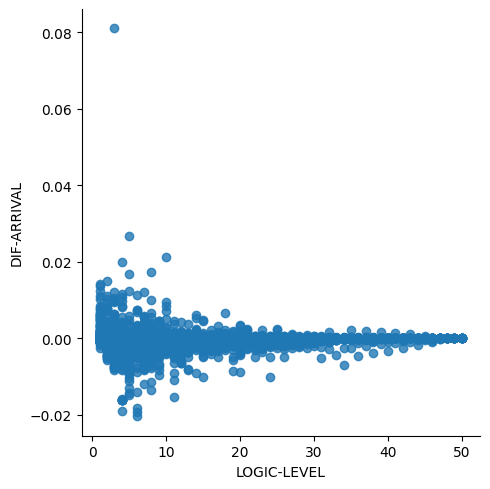

In [9]:
sns.lmplot(x="LOGIC-LEVEL", y="DIF-ARRIVAL", data=df, order = 1, ci = None)

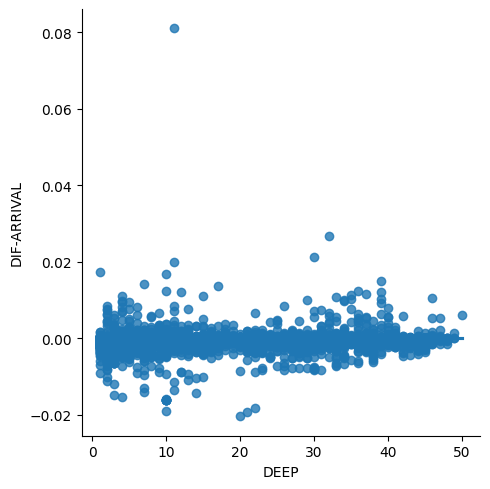

In [10]:
sns.lmplot(x="DEEP", y="DIF-ARRIVAL", data=df, order = 1, ci = None)

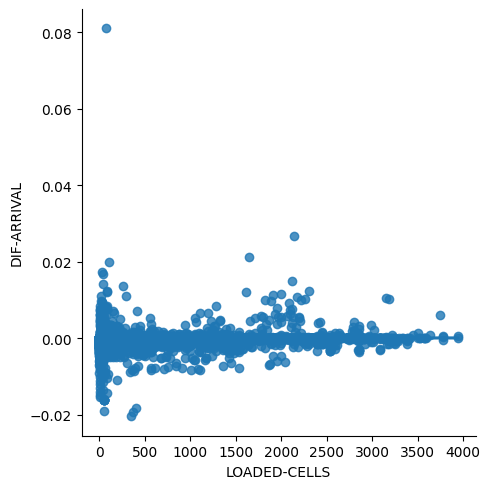

In [11]:
sns.lmplot(x="LOADED-CELLS", y="DIF-ARRIVAL", data=df, order = 1, ci = None)

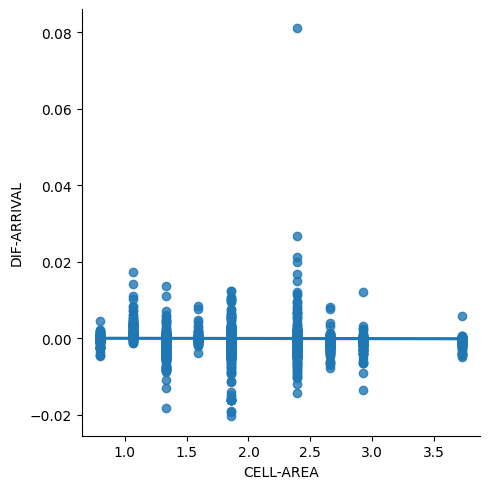

In [12]:
sns.lmplot(x="CELL-AREA", y="DIF-ARRIVAL", data=df, order = 1, ci = None)

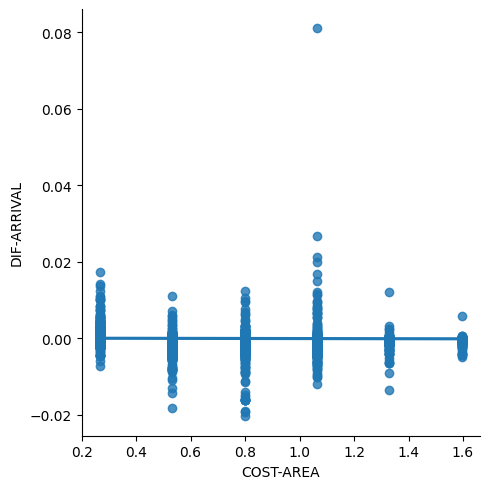

In [13]:
sns.lmplot(x="COST-AREA", y="DIF-ARRIVAL", data=df, order = 1, ci = None)

Corelação entre as features e o target

In [14]:
print("Pearson")
for feature in features:
    corr, p_value = pearsonr(
        df[feature],
        df["DIF-ARRIVAL"]
    )

    print(f"{feature}: {corr:.4f} (p-value: {p_value:.4e})")

Pearson
PATH-OCURENCE: 0.1221 (p-value: 6.2428e-145)
PATHS-OCURENCE: 0.1820 (p-value: 2.8656e-322)
FA-IN: -0.0326 (p-value: 9.7232e-12)
FA-OUT: 0.0865 (p-value: 2.2223e-73)
LOGIC-LEVEL: 0.0455 (p-value: 1.7580e-21)
DEEP: -0.0005 (p-value: 9.2097e-01)
LOADED-CELLS: 0.0186 (p-value: 9.9061e-05)
CELL-AREA: -0.0326 (p-value: 8.4752e-12)
COST-AREA: -0.0449 (p-value: 5.6736e-21)


In [15]:
print("Spearman")
for feature in features:
    corr, p_value = spearmanr(
        df[feature],
        df["DIF-ARRIVAL"]
    )


    print(f"{feature}: {corr:.4f} (p-value: {p_value:.4e})")

Spearman
PATH-OCURENCE: 0.0051 (p-value: 2.8717e-01)
PATHS-OCURENCE: -0.1883 (p-value: 0.0000e+00)
FA-IN: -0.2580 (p-value: 0.0000e+00)
FA-OUT: 0.2905 (p-value: 0.0000e+00)
LOGIC-LEVEL: -0.1006 (p-value: 9.9964e-99)
DEEP: 0.2204 (p-value: 0.0000e+00)
LOADED-CELLS: 0.2472 (p-value: 0.0000e+00)
CELL-AREA: -0.2171 (p-value: 0.0000e+00)
COST-AREA: -0.2160 (p-value: 0.0000e+00)


Treinando a Regreção linear

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

Medindo a qualidade do modelo

In [17]:
y_pred = model.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)

print(f"r2 = {r2:.8f}")
print(f"MSE = {mse:.8f}")
print(f"RMSE = {rmse:.8f}")
print(f"MAE = {mae:.8f}")


r2 = 0.05651504
MSE = 0.00000052
RMSE = 0.00072317
MAE = 0.00022931


Análise de Resíduos
 - Diferença entre os valores reais e preditados
 - Exatamente em zero o modelo acertou, acima de zero valor real maior que o previsto, abaixo de zero valor real menor que o previsto

 https://www.qualtrics.com/support/stats-iq/analyses/regression-guides/interpreting-residual-plots-improve-regression/

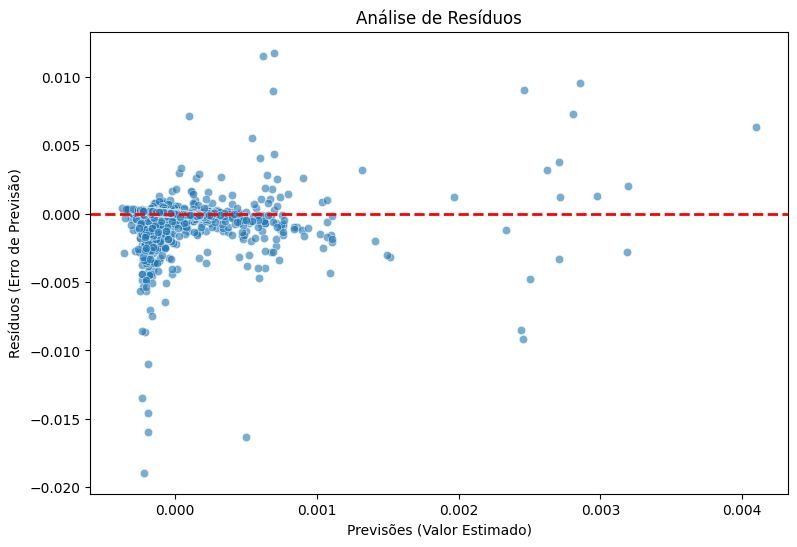

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)


plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel('Previsões (Valor Estimado)')
plt.ylabel('Resíduos (Erro de Previsão)')
plt.title('Análise de Resíduos')
plt.show()

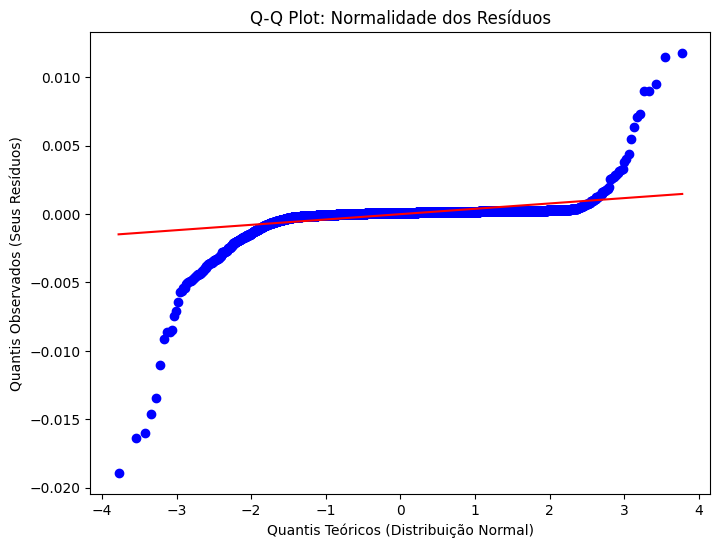

In [19]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(8, 6))

# Gera o Q-Q plot comparando os resíduos com uma distribuição normal teórica ("norm")
stats.probplot(residuals, dist="norm", plot=plt)

plt.title('Q-Q Plot: Normalidade dos Resíduos')
plt.xlabel('Quantis Teóricos (Distribuição Normal)')
plt.ylabel('Quantis Observados (Seus Resíduos)')

plt.show()

Treinando e salvando ISCAS

In [20]:
input_iscas = "iscas.csv"
df_iscas = pd.read_csv(input_iscas)

features_iscas = df_iscas[[
  "PATH-OCURENCE",
  "PATHS-OCURENCE",
  "FA-IN",
  "FA-OUT" ,
  "LOGIC-LEVEL",
  "DEEP",
  "LOADED-CELLS",
  "CELL-AREA",
  "COST-AREA",
]]

target_iscas = df_iscas["DIF-ARRIVAL"]

model_iscas = LinearRegression()
model_iscas.fit(features_iscas, target_iscas)



LinearRegression()

In [23]:
file_iscas = "iscas.pkl"
joblib.dump(model_iscas, file_iscas)


['iscas.pkl']

Treinando e salvando ITC

In [24]:
input_itc = "itc.csv"
df_itc = pd.read_csv(input_iscas)

features_itc = df_itc[[
  "PATH-OCURENCE",
  "PATHS-OCURENCE",
  "FA-IN",
  "FA-OUT" ,
  "LOGIC-LEVEL",
  "DEEP",
  "LOADED-CELLS",
  "CELL-AREA",
  "COST-AREA",
]]

target_itc = df_itc["DIF-ARRIVAL"]

model_itc = LinearRegression()
model_itc.fit(features_itc, target_itc)

LinearRegression()

In [25]:
file_itc = "itc.pkl"
joblib.dump(model_itc, file_itc)


['itc.pkl']